In [1]:
# ---------------------------------------------------------------------------
# From prediction to decision: maintenance scheduling
# ---------------------------------------------------------------------------
# 02 ends with a predicted RUL per engine. A planner cannot act on that directly
# -- the question on their desk is "which engines go into the shop this week?",
# and the shop has limited capacity.
#
# This notebook turns predictions into schedules and, because the true RUL of the
# test engines is known, scores what those schedules actually cost.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ortools.sat.python import cp_model

predictions = pd.read_csv('../outputs/test_predictions.csv')
val_errors = pd.read_csv('../outputs/lstm_val_errors.csv')['d'].values
rolling = pd.read_csv('../outputs/rolling_predictions.csv')

print("Engines:", len(predictions))
print("Validation errors available for the uncertainty model:", len(val_errors))
predictions.head()

Engines: 100
Validation errors available for the uncertainty model: 3490


,unit,rul_true,rul_true_capped,pred_lr,pred_rf,pred_xgb,pred_lstm
0,1,112.0,112.0,124.866783,121.402574,123.350174,118.219120
1,2,98.0,98.0,100.570154,118.054569,115.516490,118.204030
2,3,69.0,69.0,74.814186,45.751687,52.164520,46.461636
3,4,82.0,82.0,76.370823,85.138481,76.643620,77.784280
4,5,91.0,91.0,89.683985,106.628567,107.303450,113.763610


In [2]:
# --- problem parameters -----------------------------------------------------
# HORIZON: how far ahead we plan, in cycles.
# CAPACITY: engines the shop can take per cycle. Scarcity here is what makes
#   scheduling a decision rather than a lookup.
# FAILURE_COST vs WASTE_COST: an unplanned in-service failure costs 100x one
#   wasted cycle of remaining life -- the same asymmetry the NASA score encodes.
HORIZON = 30
CAPACITY = 3
FAILURE_COST = 100
WASTE_COST = 1

rul_true = predictions['rul_true'].values
rul_pred = predictions['pred_lstm'].values
N_ENGINES = len(rul_true)

print("Slots available:", HORIZON * CAPACITY, "for", N_ENGINES, "engines")
print("Engines that truly fail within the horizon:", (rul_true <= HORIZON).sum())
print("Engines the LSTM thinks are critical:      ", (rul_pred <= HORIZON).sum())

Slots available: 90 for 100 engines
Engines that truly fail within the horizon: 25
Engines the LSTM thinks are critical:       24


In [3]:
def evaluate_schedule(schedule, rul_actual, horizon=HORIZON):
    """Score a schedule against the RUL that actually happened.

    schedule maps engine index -> service period, or None if deferred past the
    window. This function is the only judge in the notebook, and it never sees
    any prediction -- every strategy below is scored on the same real outcome.
    """
    failures, wasted = 0, 0
    for i, period in schedule.items():
        actual = rul_actual[i]
        if period is None:
            if actual <= horizon:
                failures += 1        # left in service and it broke
        elif period > actual:
            failures += 1            # the shop slot came too late
        else:
            wasted += actual - period

    return {
        'failures': failures,
        'wasted_life': int(round(wasted)),
        'total_cost': failures * FAILURE_COST + int(round(wasted)) * WASTE_COST,
    }

In [4]:
# --- two ways to price a maintenance slot -----------------------------------
# The optimiser needs cost[i][t] (servicing engine i in period t) and a cost for
# deferring it. How those numbers are built is the whole story of this notebook.

def point_estimate_costs(rul_estimate, horizon=HORIZON):
    """Treat the predicted RUL as if it were the truth.

    The late branch grows with lateness so that servicing an overdue engine
    tomorrow still beats abandoning it -- without that term the optimiser is
    indifferent between the two and simply abandons.
    """
    n = len(rul_estimate)
    cost = np.zeros((n, horizon + 1), dtype=int)
    defer = np.zeros(n, dtype=int)

    for i, est in enumerate(rul_estimate):
        for t in range(1, horizon + 1):
            if t <= est:
                cost[i, t] = int(round(est - t)) * WASTE_COST
            else:
                cost[i, t] = FAILURE_COST + int(round(t - est)) * WASTE_COST
        defer[i] = 0 if est > horizon else FAILURE_COST + int(round(horizon + 1 - est)) * WASTE_COST

    return cost, defer


def expected_costs(pred, errors, horizon=HORIZON):
    """Price each slot against the model's whole error distribution.

    The LSTM's validation errors are d = predicted - true, so a plausible true
    RUL for an engine predicted at p is p - d for every observed d. Running the
    empirical distribution through the cost function gives the *expected* cost of
    each slot instead of the cost under one optimistic guess -- the optimiser
    then decides for itself how much buffer each engine deserves.
    """
    n = len(pred)
    cost = np.zeros((n, horizon + 1), dtype=int)
    defer = np.zeros(n, dtype=int)

    for i, p in enumerate(pred):
        possible = p - errors                       # sampled true RULs
        for t in range(1, horizon + 1):
            fails = possible < t
            p_fail = fails.mean()
            survived = possible[~fails]
            mean_waste = (survived - t).mean() if survived.size else 0.0
            cost[i, t] = int(round(p_fail * FAILURE_COST + (1 - p_fail) * mean_waste * WASTE_COST))

        p_fail_defer = (possible <= horizon).mean()
        defer[i] = int(round(p_fail_defer * (FAILURE_COST + 0.5 * horizon)))

    return cost, defer

In [5]:
def solve_schedule(cost, defer, horizon=HORIZON, capacity=CAPACITY, verbose=False):
    """Exact maintenance schedule via CP-SAT, given a priced cost matrix.

    x[i, t] = 1 when engine i is serviced in period t. Leaving every x[i, t] at
    zero means deferring the engine past the window, priced by defer[i].
    """
    n = cost.shape[0]
    model = cp_model.CpModel()

    x = {(i, t): model.NewBoolVar(f'x_{i}_{t}')
         for i in range(n) for t in range(1, horizon + 1)}

    for i in range(n):                       # each engine at most one slot
        model.Add(sum(x[i, t] for t in range(1, horizon + 1)) <= 1)

    for t in range(1, horizon + 1):          # the shop cannot be oversubscribed
        model.Add(sum(x[i, t] for i in range(n)) <= capacity)

    terms = []
    for i in range(n):
        for t in range(1, horizon + 1):
            terms.append(int(cost[i, t]) * x[i, t])
        # (1 - sum_t x[i,t]) equals 1 exactly when engine i is deferred.
        terms.append(int(defer[i]) * (1 - sum(x[i, t] for t in range(1, horizon + 1))))

    model.Minimize(sum(terms))

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 120.0
    solver.parameters.num_workers = 8
    status = solver.Solve(model)

    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        raise RuntimeError(f'no solution: {solver.StatusName(status)}')

    if verbose:
        print(f'  {solver.StatusName(status)}  planned cost={solver.ObjectiveValue():.0f}  '
              f'{solver.WallTime():.2f}s')

    return {i: next((t for t in range(1, horizon + 1) if solver.Value(x[i, t])), None)
            for i in range(n)}

In [6]:
# --- baseline 1: calendar-based preventive maintenance ----------------------
# The traditional approach: ignore condition data and work through the fleet at a
# fixed rate. This is the thing predictive maintenance is supposed to beat.
def fixed_interval_schedule(n, horizon=HORIZON, capacity=CAPACITY):
    return {i: (i // capacity + 1 if i // capacity + 1 <= horizon else None)
            for i in range(n)}


# --- baseline 2: greedy triage ----------------------------------------------
# What a planner would do with the predictions but no solver: most urgent engine
# first, booked as late as it can safely go so as not to waste life. Myopic -- it
# never revisits an earlier booking when a more urgent engine shows up later.
def greedy_schedule(rul_estimate, horizon=HORIZON, capacity=CAPACITY):
    remaining = {t: capacity for t in range(1, horizon + 1)}
    schedule = {}

    for i in np.argsort(rul_estimate):
        if rul_estimate[i] > horizon:
            schedule[i] = None
            continue

        latest = int(min(horizon, np.floor(rul_estimate[i])))
        chosen = next((t for t in range(max(latest, 1), 0, -1) if remaining[t] > 0), None)
        if chosen is None:
            chosen = next((t for t in range(1, horizon + 1) if remaining[t] > 0), None)

        schedule[i] = chosen
        if chosen is not None:
            remaining[chosen] -= 1

    return schedule

In [7]:
# --- the safety margin ------------------------------------------------------
# A middle ground between trusting the point estimate and modelling the whole
# distribution: shift every prediction down by a fixed number of cycles.
#
# The margin is read off the *validation* errors. Reading it off the test outcome
# would be tuning on the set we report on -- the same mistake the test-set
# evaluation in 02 was added to avoid.
for q in [50, 75, 90, 95, 99]:
    print(f'  {q}th percentile of d: {np.percentile(val_errors, q):6.2f}')

SAFETY_QUANTILE = 90       # chosen a priori: cover 90% of the error distribution
safety_margin = np.percentile(val_errors, SAFETY_QUANTILE)
rul_robust = np.maximum(rul_pred - safety_margin, 0)

print(f'\nSafety margin ({SAFETY_QUANTILE}th pct): {safety_margin:.2f} cycles')
print(f'Engines treated as critical: {(rul_robust <= HORIZON).sum()} (was {(rul_pred <= HORIZON).sum()})')

  50th percentile of d:  -0.42
  75th percentile of d:   7.93
  90th percentile of d:  19.15
  95th percentile of d:  27.89
  99th percentile of d:  40.90

Safety margin (90th pct): 19.15 cycles
Engines treated as critical: 30 (was 24)


In [8]:
# --- run every strategy -----------------------------------------------------
strategies = {}
strategies['Fixed interval'] = fixed_interval_schedule(N_ENGINES)
strategies['Greedy (raw)'] = greedy_schedule(rul_pred)
strategies['Greedy (margin)'] = greedy_schedule(rul_robust)

print('CP-SAT, raw predictions:')
strategies['CP-SAT (raw)'] = solve_schedule(*point_estimate_costs(rul_pred), verbose=True)

print('CP-SAT, safety margin:')
strategies['CP-SAT (margin)'] = solve_schedule(*point_estimate_costs(rul_robust), verbose=True)

print('CP-SAT, expected cost over the error distribution:')
strategies['CP-SAT (expected cost)'] = solve_schedule(*expected_costs(rul_pred, val_errors), verbose=True)

# Upper bound: a planner with a perfect crystal ball. Unreachable, but it shows
# how much of the remaining gap is prediction error rather than bad scheduling.
print('CP-SAT, perfect information:')
strategies['CP-SAT (perfect info)'] = solve_schedule(*point_estimate_costs(rul_true), verbose=True)

results = pd.DataFrame([
    {'strategy': name, **evaluate_schedule(sched, rul_true)}
    for name, sched in strategies.items()
])
results['scheduled'] = [sum(1 for v in s.values() if v is not None) for s in strategies.values()]
results = results.sort_values('total_cost').reset_index(drop=True)
results

CP-SAT, raw predictions:
  OPTIMAL  planned cost=15  0.03s
CP-SAT, safety margin:
  OPTIMAL  planned cost=1155  0.02s
CP-SAT, expected cost over the error distribution:
  OPTIMAL  planned cost=935  0.02s
CP-SAT, perfect information:


  OPTIMAL  planned cost=1  0.02s


,strategy,failures,wasted_life,total_cost,scheduled
0,CP-SAT (perfect info),0,1,1,25
1,Greedy (margin),0,435,435,30
2,CP-SAT (margin),0,435,435,30
3,CP-SAT (expected cost),1,381,481,27
4,Greedy (raw),15,38,1538,24
5,CP-SAT (raw),15,38,1538,24
6,Fixed interval,13,5512,6812,90


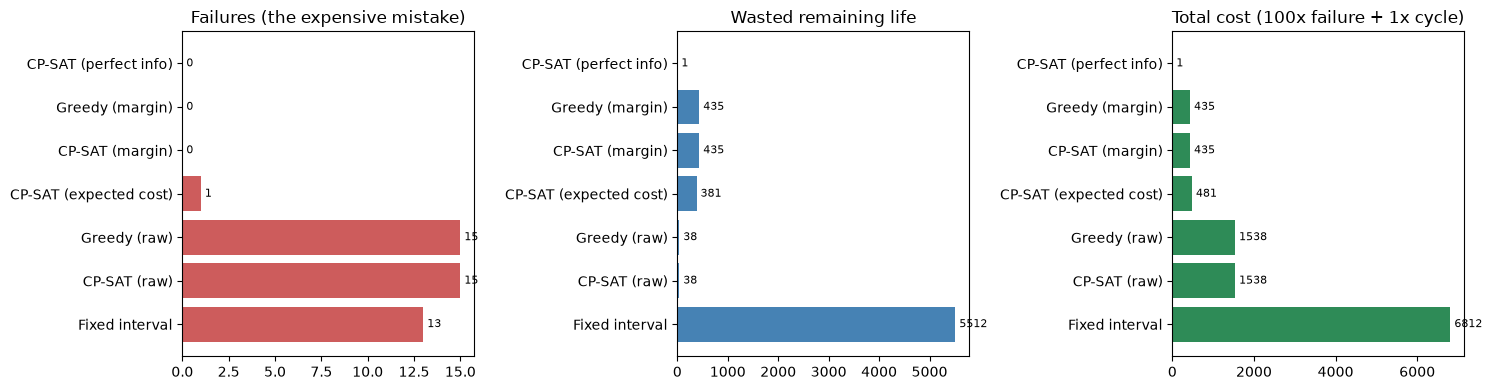

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
order = results['strategy'].tolist()

for axis, col, colour, title in [
    (ax[0], 'failures', 'indianred', 'Failures (the expensive mistake)'),
    (ax[1], 'wasted_life', 'steelblue', 'Wasted remaining life'),
    (ax[2], 'total_cost', 'seagreen', f'Total cost ({FAILURE_COST}x failure + 1x cycle)'),
]:
    axis.barh(order, results[col], color=colour)
    axis.invert_yaxis()
    axis.set_title(title)
    for y, v in enumerate(results[col]):
        axis.text(v, y, f' {v}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

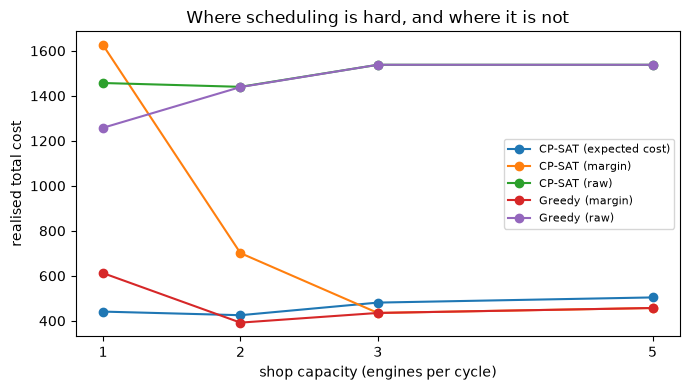

capacity,1,2,3,5
strategy,,,,
CP-SAT (expected cost),441,425,481,504
CP-SAT (margin),1625,701,435,457
CP-SAT (raw),1457,1440,1538,1538
Greedy (margin),612,392,435,457
Greedy (raw),1258,1439,1538,1538


In [10]:
# --- when does exact optimisation actually pay? -----------------------------
# CP-SAT and greedy tie at CAPACITY=3, which is worth taking seriously rather
# than glossing over: at that capacity nothing is contended. Every engine can be
# booked at its own deadline, so there is no scheduling conflict left to resolve
# and an exact solver has nothing to add over a sensible heuristic.
#
# Tightening capacity is the honest way to find out where the boundary is.
capacity_rows = []
for cap in [1, 2, 3, 5]:
    for name, sched in [
        ('Greedy (raw)', greedy_schedule(rul_pred, capacity=cap)),
        ('CP-SAT (raw)', solve_schedule(*point_estimate_costs(rul_pred), capacity=cap)),
        ('Greedy (margin)', greedy_schedule(rul_robust, capacity=cap)),
        ('CP-SAT (margin)', solve_schedule(*point_estimate_costs(rul_robust), capacity=cap)),
        ('CP-SAT (expected cost)', solve_schedule(*expected_costs(rul_pred, val_errors), capacity=cap)),
    ]:
        capacity_rows.append({'capacity': cap, 'strategy': name,
                              **evaluate_schedule(sched, rul_true)})

capacity_df = pd.DataFrame(capacity_rows)
capacity_pivot = capacity_df.pivot(index='strategy', columns='capacity', values='total_cost')

fig, ax = plt.subplots(figsize=(7, 4))
for name in capacity_pivot.index:
    ax.plot(capacity_pivot.columns, capacity_pivot.loc[name], 'o-', label=name)
ax.set_xlabel('shop capacity (engines per cycle)'); ax.set_ylabel('realised total cost')
ax.set_xticks(capacity_pivot.columns); ax.legend(fontsize=8)
ax.set_title('Where scheduling is hard, and where it is not')
plt.tight_layout(); plt.show()

capacity_pivot

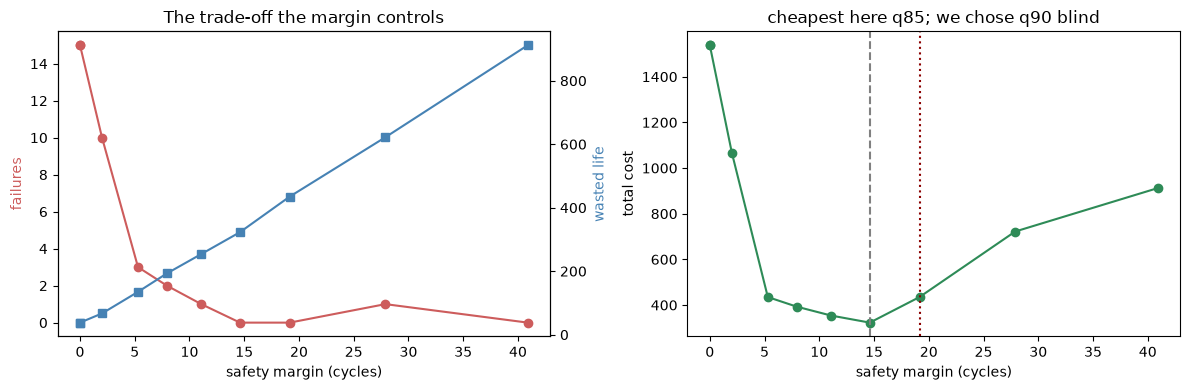

,quantile,margin,failures,wasted_life,total_cost
0,0,0.000000,15,38,1538
1,50,0.000000,15,38,1538
2,60,2.013166,10,67,1067
3,70,5.298002,3,135,435
4,75,7.933365,2,193,393
5,80,11.075943,1,254,354
6,85,14.613436,0,323,323
7,90,19.152405,0,435,435
8,95,27.889789,1,622,722
9,99,40.898365,0,912,912


In [11]:
# --- how much margin? -------------------------------------------------------
# Bigger margins pull maintenance forward: fewer failures, more life discarded.
# This sweep is a diagnostic, NOT how the margin above was chosen.
sweep = []
for q in [0, 50, 60, 70, 75, 80, 85, 90, 95, 99]:
    margin = max(np.percentile(val_errors, q), 0) if q > 0 else 0.0
    sched = solve_schedule(*point_estimate_costs(np.maximum(rul_pred - margin, 0)))
    sweep.append({'quantile': q, 'margin': margin, **evaluate_schedule(sched, rul_true)})

sweep_df = pd.DataFrame(sweep)
best = sweep_df.loc[sweep_df['total_cost'].idxmin()]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(sweep_df['margin'], sweep_df['failures'], 'o-', color='indianred')
ax0b = ax[0].twinx()
ax0b.plot(sweep_df['margin'], sweep_df['wasted_life'], 's-', color='steelblue')
ax[0].set_xlabel('safety margin (cycles)')
ax[0].set_ylabel('failures', color='indianred'); ax0b.set_ylabel('wasted life', color='steelblue')
ax[0].set_title('The trade-off the margin controls')

ax[1].plot(sweep_df['margin'], sweep_df['total_cost'], 'o-', color='seagreen')
ax[1].axvline(best['margin'], linestyle='--', color='grey')
ax[1].axvline(safety_margin, linestyle=':', color='darkred')
ax[1].set_xlabel('safety margin (cycles)'); ax[1].set_ylabel('total cost')
ax[1].set_title(f"cheapest here q{int(best['quantile'])}; we chose q{SAFETY_QUANTILE} blind")
plt.tight_layout(); plt.show()

sweep_df

In [12]:
# ---------------------------------------------------------------------------
# Rolling horizon
# ---------------------------------------------------------------------------
# Everything above is a single static plan: decide once, never revisit. Real
# planning is rolling -- every cycle brings fresh sensor data, the prediction
# moves, and only the immediate decision is actually committed.
#
# 02 exported a prediction per engine per cycle for the last ROLL_CYCLES cycles
# of each test engine's record, which is what makes the simulation possible.
K = rolling['offset_from_end'].max() + 1
roll_units = sorted(rolling['unit'].unique())
n_roll = len(roll_units)

# pred_at[i, tau] = prediction for engine i at simulation cycle tau.
# offset counts backwards from truncation, so tau = 0 is the earliest point.
pivot_pred = rolling.pivot(index='unit', columns='offset_from_end', values='pred_lstm')
pivot_true = rolling.pivot(index='unit', columns='offset_from_end', values='rul_true')
pred_at = pivot_pred[sorted(pivot_pred.columns, reverse=True)].values
rul0 = pivot_true[K - 1].values            # true RUL at tau = 0

print(f'Fleet: {n_roll} engines, {K} simulated cycles')
print(f'True RUL at simulation start: min {rul0.min():.0f}, median {np.median(rul0):.0f}')

# Prediction accuracy as an engine approaches the end of its record -- the reason
# re-planning is worth anything at all.
acc = rolling.assign(err=lambda d: d.pred_lstm - d.rul_true).groupby('offset_from_end')['err']
acc_df = pd.DataFrame({'rmse': np.sqrt((acc.apply(lambda s: (s ** 2).mean()))),
                       'bias': acc.mean()})
acc_df.index.name = 'cycles before truncation'
acc_df.head(K)

Fleet: 96 engines, 15 simulated cycles
True RUL at simulation start: min 21, median 98


,rmse,bias
cycles before truncation,,
0,14.601075,2.725216
1,14.481714,3.071434
2,15.397835,3.367472
3,16.321330,3.575664
4,16.362944,3.450856
5,16.337902,2.630370
6,16.436996,2.389116
7,17.332902,1.763336
8,17.560193,1.169096


In [13]:
def rolling_simulation(cost_builder, capacity=CAPACITY, horizon=HORIZON, sim_cycles=K):
    """Re-plan every cycle, commit only the next cycle's bookings.

    Returns absolute service time per engine, measured from tau = 0, so it is
    directly comparable with a static plan built at tau = 0.
    """
    service_time = {}
    active = list(range(n_roll))

    for tau in range(sim_cycles):
        if not active:
            break

        cost, defer = cost_builder(pred_at[active, tau])
        sched = solve_schedule(cost, defer, horizon=horizon, capacity=capacity)

        # Only the imminent bookings are real commitments; the rest is a plan
        # that the next cycle's fresh predictions are free to overwrite.
        committed = [active[k] for k, t in sched.items() if t == 1]
        for i in committed:
            service_time[i] = tau + 1
        active = [i for i in active if i not in set(committed)]

    # Whatever is still in service at the end keeps the final plan.
    if active:
        cost, defer = cost_builder(pred_at[active, sim_cycles - 1])
        sched = solve_schedule(cost, defer, horizon=horizon, capacity=capacity)
        for k, t in sched.items():
            service_time[active[k]] = (sim_cycles - 1 + t) if t is not None else None

    return service_time


def score_absolute(service_time, horizon=HORIZON):
    """Score absolute service times against the true RUL at tau = 0."""
    failures, wasted = 0, 0
    for i, when in service_time.items():
        if when is None:
            if rul0[i] <= horizon:
                failures += 1
        elif when > rul0[i]:
            failures += 1
        else:
            wasted += rul0[i] - when
    return {'failures': failures, 'wasted_life': int(round(wasted)),
            'total_cost': failures * FAILURE_COST + int(round(wasted)) * WASTE_COST}

In [14]:
# Static plan for the same fleet: decide once at tau = 0 and never look again.
#
# READ THE CAVEAT BELOW BEFORE DRAWING CONCLUSIONS FROM THIS TABLE. The test
# trajectories stop at truncation, so the simulation can only roll ~15 cycles,
# and the least healthy engine in the fleet still has 21 cycles of life at the
# start. Nothing can actually fail inside the simulated window, and only ~7
# engines are urgent enough to be committed during it -- the rest fall through to
# the final plan, whose service times are shifted out by the 14 cycles already
# elapsed. So the comparison is dominated by that end-of-window handling rather
# than by whether re-planning helps, and the fact that rolling comes out worse
# here is an artefact of the setup, not evidence against rolling horizons.
#
# Doing this properly needs trajectories that continue past the decision point,
# which FD001's test split does not provide.
static_rows = {}
for name, builder in [
    ('raw', lambda p: point_estimate_costs(p)),
    ('margin', lambda p: point_estimate_costs(np.maximum(p - safety_margin, 0))),
    ('expected cost', lambda p: expected_costs(p, val_errors)),
]:
    cost, defer = builder(pred_at[:, 0])
    static_sched = solve_schedule(cost, defer)
    static_rows[f'Static plan ({name})'] = score_absolute(
        {i: t for i, t in static_sched.items()}
    )

    rolling_service = rolling_simulation(builder)
    static_rows[f'Rolling horizon ({name})'] = score_absolute(rolling_service)

rolling_results = pd.DataFrame(static_rows).T.reset_index()
rolling_results.columns = ['strategy', 'failures', 'wasted_life', 'total_cost']
rolling_results = rolling_results.sort_values('total_cost').reset_index(drop=True)

print(f'Engines that can fail inside the {K}-cycle window:', (rul0 <= K).sum(), 'of', n_roll)
print('Engines urgent enough to commit at simulation start:', (pred_at[:, 0] <= HORIZON).sum())
rolling_results

Engines that can fail inside the 15-cycle window: 0 of 96
Engines urgent enough to commit at simulation start: 7


,strategy,failures,wasted_life,total_cost
0,Static plan (expected cost),0,250,250
1,Static plan (margin),0,346,346
2,Rolling horizon (expected cost),0,517,517
3,Rolling horizon (margin),0,573,573
4,Static plan (raw),8,6,806
5,Rolling horizon (raw),12,38,1238


In [15]:
# --- cross-check the CP-SAT optimum with Gurobi -----------------------------
# Same model, different solver. Two independent solvers landing on the same
# objective value is decent evidence the formulation says what it is meant to.
# Wrapped so the notebook still runs end to end without a Gurobi licence.
try:
    import gurobipy as gp
    from gurobipy import GRB

    cost, defer = point_estimate_costs(rul_robust)
    n = cost.shape[0]

    gm = gp.Model('maintenance')
    gm.setParam('OutputFlag', 0)

    x = gm.addVars(n, range(1, HORIZON + 1), vtype=GRB.BINARY, name='x')

    for i in range(n):
        gm.addConstr(gp.quicksum(x[i, t] for t in range(1, HORIZON + 1)) <= 1)
    for t in range(1, HORIZON + 1):
        gm.addConstr(gp.quicksum(x[i, t] for i in range(n)) <= CAPACITY)

    gm.setObjective(
        gp.quicksum(int(cost[i, t]) * x[i, t] for i in range(n) for t in range(1, HORIZON + 1))
        + gp.quicksum(int(defer[i]) * (1 - gp.quicksum(x[i, t] for t in range(1, HORIZON + 1)))
                      for i in range(n)),
        GRB.MINIMIZE,
    )
    gm.optimize()

    gurobi_sched = {i: next((t for t in range(1, HORIZON + 1) if x[i, t].X > 0.5), None)
                    for i in range(n)}
    gurobi_outcome = evaluate_schedule(gurobi_sched, rul_true)

    print(f'Gurobi   objective {gm.ObjVal:.0f}   {gm.Runtime:.2f}s')
    print(f'CP-SAT   realised  {evaluate_schedule(strategies["CP-SAT (margin)"], rul_true)}')
    print(f'Gurobi   realised  {gurobi_outcome}')

except Exception as exc:                       # no licence, or none installed
    print('Gurobi cross-check skipped:', exc)

Set parameter Username


Set parameter LicenseID to value 2813581


Academic license - for non-commercial use only - expires 2027-04-27


Gurobi   objective 1155   0.01s
CP-SAT   realised  {'failures': 0, 'wasted_life': 435, 'total_cost': 435}
Gurobi   realised  {'failures': 0, 'wasted_life': 435, 'total_cost': 435}


In [16]:
# --- does the ranking survive a different price ratio? ----------------------
# FAILURE_COST = 100 was an assumption. Re-scoring the same schedules under other
# ratios shows whether the conclusion depends on it.
ratio_rows = []
for fc in [20, 50, 100, 200, 500]:
    for name, sched in strategies.items():
        outcome = evaluate_schedule(sched, rul_true)
        ratio_rows.append({'failure_cost': fc, 'strategy': name,
                           'total_cost': outcome['failures'] * fc + outcome['wasted_life']})

ratio_df = (pd.DataFrame(ratio_rows)
            .pivot(index='strategy', columns='failure_cost', values='total_cost')
            .loc[results['strategy']])
ratio_df

failure_cost,20,50,100,200,500
strategy,,,,,
CP-SAT (perfect info),1,1,1,1,1
Greedy (margin),435,435,435,435,435
CP-SAT (margin),435,435,435,435,435
CP-SAT (expected cost),401,431,481,581,881
Greedy (raw),338,788,1538,3038,7538
CP-SAT (raw),338,788,1538,3038,7538
Fixed interval,5772,6162,6812,8112,12012
